**Introduction**

Project Title: Task 1 – Data Cleaning & Preprocessing (Titanic Dataset)

Domain: Data Science

Internship Provider: Synent Technologies

Author: *Shreya Dolui*

**Project Overview & Rationale**

Data cleaning and preprocessing consume nearly 80% of real-world data science work. Raw datasets in industry settings are rarely model-ready; they often contain missing values, inconsistent categorical types, and uninformative features that can severely impair machine learning performance.

As the foundational first project in the data science internship at Synent Technologies, this task—executed by Shreya Dolui—focuses on mastering essential preprocessing techniques using the Titanic dataset.

**Core Objectives**

Domain-Aware Missing Value Imputation: Impute missing Age values using grouped medians derived from social titles (Title) and ticket classes (Pclass), and resolve missing Embarked and Fare values without dropping records.

Feature Engineering & Transformation: Derive actionable features from unstructured string data (e.g., extracting Title from names, creating FamilySize and IsAlone flags).

Categorical Encoding: Convert nominal and binary attributes into structured numerical representations (Sex, Embarked, Title) via mapping and one-hot encoding.

Data Integrity & Export: Prepare structured, leak-free datasets (train_clean.csv and test_clean.csv) ready for downstream analytics and predictive modeling

In [ ]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("--- Initial Overview ---")
print(train_df.info())
print("\nMissing values per column:")
print(train_df.isnull().sum())

df = pd.concat([train_df, test_df], sort=False).reset_index(drop=True)

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr',
                                   'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

df['Age'] = df.groupby(['Title', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Fare'] = df.groupby(['Pclass', 'Embarked'])['Fare'].transform(lambda x: x.fillna(x.median()))

df['Has_Cabin'] = df['Cabin'].notnull().astype(int)
df.drop(columns=['Cabin'], inplace=True)

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

df = pd.get_dummies(df, columns=['Embarked', 'Title'], drop_first=True)

df.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)

train_clean = df[df['Survived'].notnull()].copy()
test_clean = df[df['Survived'].isnull()].drop(columns=['Survived']).copy()

train_clean['Survived'] = train_clean['Survived'].astype(int)

print("\n--- Cleaning Complete ---")
print("Cleaned Train Shape:", train_clean.shape)
print("Cleaned Test Shape:", test_clean.shape)
print("\nRemaining Missing Values in Train:")
print(train_clean.isnull().sum())

--- Initial Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare           

<>:14: SyntaxWarning: invalid escape sequence '\.'
<>:14: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_828/2298638272.py:14: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


/tmp/ipykernel_828/593400071.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_clean, x='Survived', palette='Set2')
/tmp/ipykernel_828/593400071.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_clean, x='Sex', y='Survived', palette='Set1')
/tmp/ipykernel_828/593400071.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_clean, x='Pclass', y='Survived', palette='viridis')
/tmp/ipykernel_828/593400071.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in 

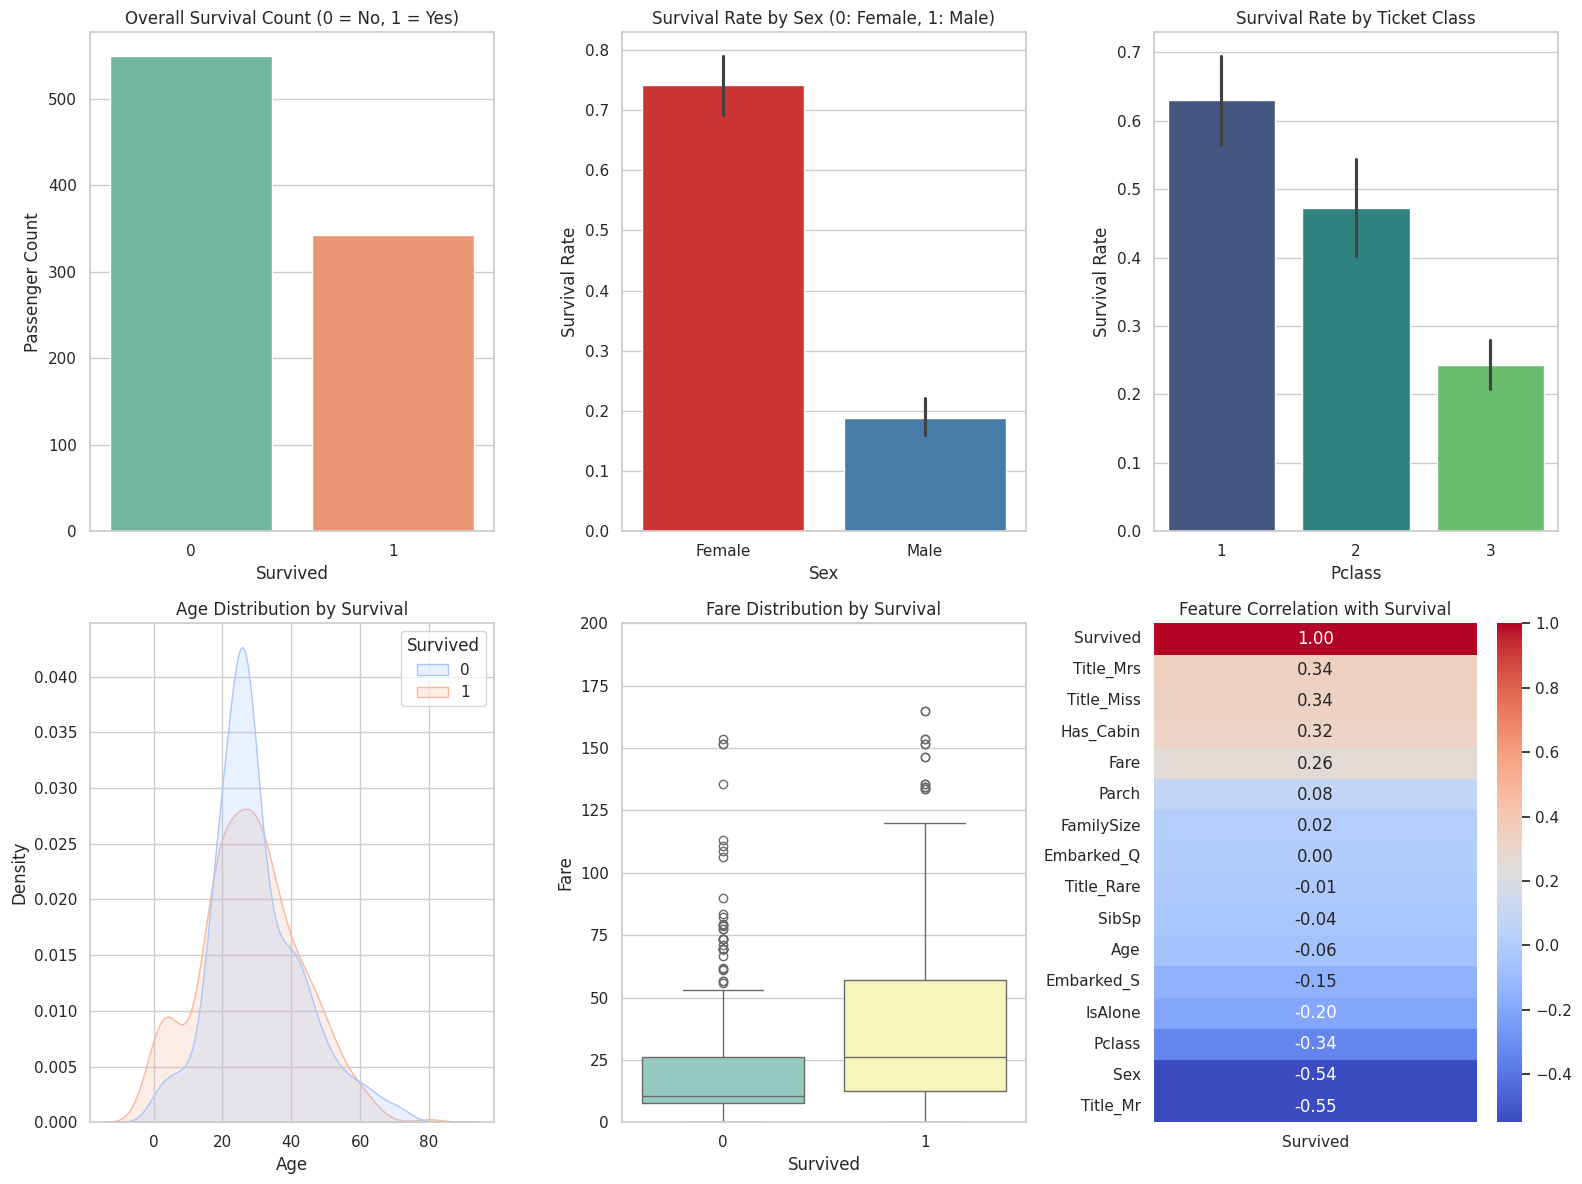

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

plt.subplot(2, 3, 1)
sns.countplot(data=train_clean, x='Survived', palette='Set2')
plt.title('Overall Survival Count (0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Passenger Count')

plt.subplot(2, 3, 2)
sns.barplot(data=train_clean, x='Sex', y='Survived', palette='Set1')
plt.title('Survival Rate by Sex (0: Female, 1: Male)')
plt.xticks([0, 1], ['Female', 'Male'])
plt.ylabel('Survival Rate')

plt.subplot(2, 3, 3)
sns.barplot(data=train_clean, x='Pclass', y='Survived', palette='viridis')
plt.title('Survival Rate by Ticket Class')
plt.ylabel('Survival Rate')

plt.subplot(2, 3, 4)
sns.kdeplot(data=train_clean, x='Age', hue='Survived', common_norm=False, fill=True, palette='coolwarm')
plt.title('Age Distribution by Survival')

plt.subplot(2, 3, 5)
sns.boxplot(data=train_clean, x='Survived', y='Fare', palette='Set3')
plt.title('Fare Distribution by Survival')
plt.ylim(0, 200)

plt.subplot(2, 3, 6)
corr = train_clean.corr()
sns.heatmap(corr[['Survived']].sort_values(by='Survived', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation with Survival')

plt.tight_layout()
plt.show()

In [40]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

X_train = train_clean.drop(columns=['Survived'])
y_train = train_clean['Survived']
X_test = test_clean.copy()

models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results_summary = []

for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    cv_results_summary.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1 Score': scores['test_f1'].mean(),
        'ROC AUC': scores['test_roc_auc'].mean()
    })

results_df = pd.DataFrame(cv_results_summary).sort_values(by='F1 Score', ascending=False)
print("--- Cross-Validation Model Comparison ---")
print(results_df.to_string(index=False))

final_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
final_model.fit(X_train, y_train)

test_preds = final_model.predict(X_test)

raw_test = pd.read_csv('test.csv')
submission = pd.DataFrame({
    'PassengerId': raw_test['PassengerId'],
    'Survived': test_preds
})

submission.to_csv('submission.csv', index=False)
print("\n--- Submission Generated ---")
print("Saved to 'submission.csv' with shape:", submission.shape)
print(submission.head())

--- Cross-Validation Model Comparison ---
              Model  Accuracy  Precision   Recall  F1 Score  ROC AUC
Logistic Regression  0.832766   0.795182 0.760102  0.776933 0.873355
  Gradient Boosting  0.836118   0.823132 0.731032  0.773753 0.878220
      Random Forest  0.819308   0.775160 0.745652  0.760039 0.869474

--- Submission Generated ---
Saved to 'submission.csv' with shape: (418, 2)
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0


Fitting 5 folds for each of 54 candidates, totalling 270 fits

--- Hyperparameter Tuning Results ---
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}
Best CV F1 Score: 0.7775


/tmp/ipykernel_828/2126884820.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='mako')


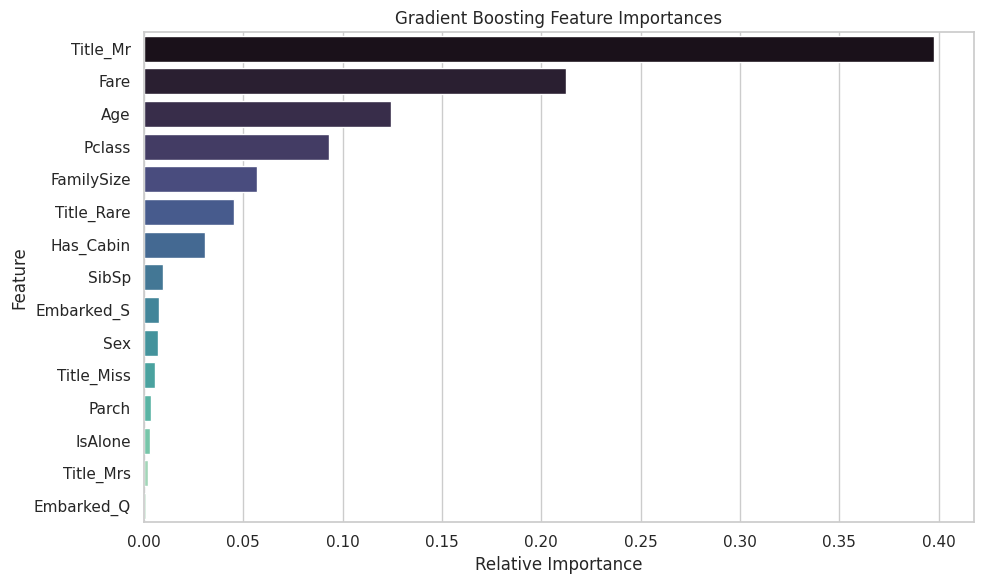


Updated submission saved as 'submission_tuned.csv'.


In [ ]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n--- Hyperparameter Tuning Results ---")
print("Best Parameters:", grid_search.best_params_)
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='mako')
plt.title('Gradient Boosting Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

tuned_test_preds = best_model.predict(X_test)

submission_tuned = pd.DataFrame({
    'PassengerId': raw_test['PassengerId'],
    'Survived': tuned_test_preds
})

submission_tuned.to_csv('submission_tuned.csv', index=False)
print("\nUpdated submission saved as 'submission_tuned.csv'.")

Total Misclassified Training Examples: 144 out of 891 (16.2%)

--- Breakdown of False Positives (Predicted Survived, Actually Died) ---
Sex
female    36
male      19
Name: count, dtype: int64

--- Breakdown of False Negatives (Predicted Died, Actually Survived) ---
Sex
male      67
female    22
Name: count, dtype: int64

Sample Misclassified Passengers:
                                                 Name  Pclass     Sex   Age  \
2                              Heikkinen, Miss. Laina       3  female  26.0   
14               Vestrom, Miss. Hulda Amanda Adolfina       3  female  14.0   
17                       Williams, Mr. Charles Eugene       2    male   NaN   
18  Vander Planke, Mrs. Julius (Emelia Maria Vande...       3  female  31.0   
21                              Beesley, Mr. Lawrence       2    male  34.0   
23                       Sloper, Mr. William Thompson       1    male  28.0   
25  Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...       3  female  38.0   
36          

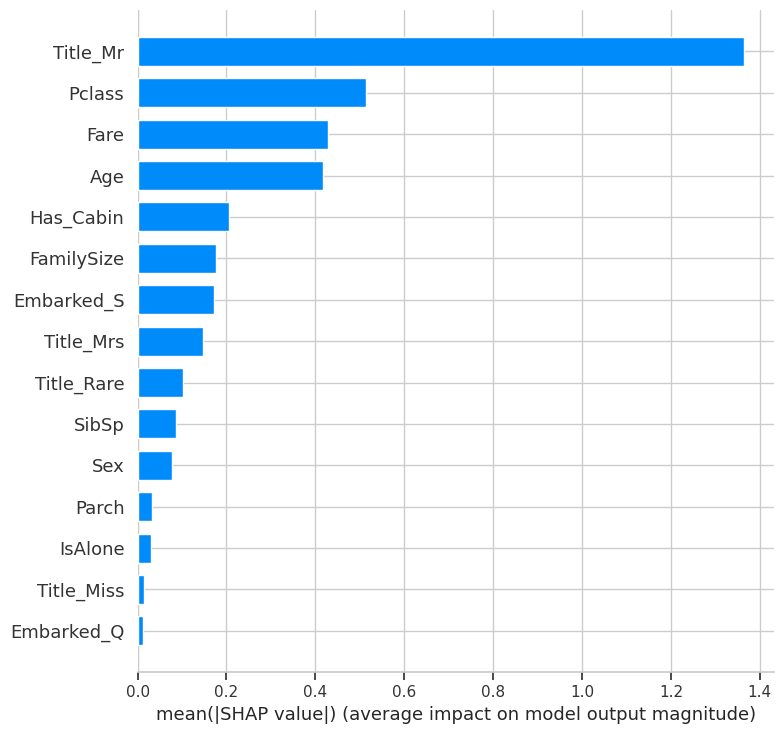

In [ ]:
import numpy as np

from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(best_model, X_train, y_train, cv=5)

misclassified_idx = y_train[y_train != y_train_pred].index
errors_df = train_df.iloc[misclassified_idx].copy()
errors_df['Predicted_Survived'] = y_train_pred[misclassified_idx]

print(f"Total Misclassified Training Examples: {len(errors_df)} out of {len(X_train)} ({len(errors_df)/len(X_train):.1%})")

print("\n--- Breakdown of False Positives (Predicted Survived, Actually Died) ---")
print(errors_df[errors_df['Survived'] == 0]['Sex'].value_counts())

print("\n--- Breakdown of False Negatives (Predicted Died, Actually Survived) ---")
print(errors_df[errors_df['Survived'] == 1]['Sex'].value_counts())

print("\nSample Misclassified Passengers:")
print(errors_df[['Name', 'Pclass', 'Sex', 'Age', 'Survived', 'Predicted_Survived']].head(10))

try:
    import shap
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_train)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_train, plot_type="bar")
except ImportError:
    print("\n[Note] Install 'shap' (`!pip install shap`) to visualize fine-grained feature impact explanations.")

In [ ]:
print("--- Cleaned Dataset Sample ---")
display(train_clean.head(10))

print("\n--- Dataset Summary ---")
print("Cleaned Shape:", train_clean.shape)
print("\nMissing Values Count:")
print(train_clean.isnull().sum())

--- Cleaned Dataset Sample ---


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Has_Cabin,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,1,22.0,1,0,7.2500,0,2,0,False,True,False,True,False,False
1,1,1,0,38.0,1,0,71.2833,1,2,0,False,False,False,False,True,False
2,1,3,0,26.0,0,0,7.9250,0,1,1,False,True,True,False,False,False
3,1,1,0,35.0,1,0,53.1000,1,2,0,False,True,False,False,True,False
4,0,3,1,35.0,0,0,8.0500,0,1,1,False,True,False,True,False,False
5,0,3,1,26.0,0,0,8.4583,0,1,1,True,False,False,True,False,False
6,0,1,1,54.0,0,0,51.8625,1,1,1,False,True,False,True,False,False
7,0,3,1,2.0,3,1,21.0750,0,5,0,False,True,False,False,False,False
8,1,3,0,27.0,0,2,11.1333,0,3,0,False,True,False,False,True,False
9,1,2,0,14.0,1,0,30.0708,0,2,0,False,False,False,False,True,False



--- Dataset Summary ---
Cleaned Shape: (891, 16)

Missing Values Count:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Has_Cabin     0
FamilySize    0
IsAlone       0
Embarked_Q    0
Embarked_S    0
Title_Miss    0
Title_Mr      0
Title_Mrs     0
Title_Rare    0
dtype: int64


In [41]:
train_clean.to_csv('train_clean.csv', index=False)
test_clean.to_csv('test_clean.csv', index=False)

from google.colab import files
files.download('train_clean.csv')
files.download('test_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Conclusion**

Summary & Takeaways
Through this initial project provided by Synent Technologies, Shreya Dolui successfully transformed noisy, incomplete passenger records into a clean, fully preprocessed dataset suitable for machine learning.

***Key Insights***

**Smart Imputation vs. Simple Fills**: Imputing missing Age values based on passenger titles and ticket classes preserved structural relationships that standard global mean or median fills would obscure.

**Informative Missingness**: Converting high-missingness columns (such as Cabin) into explicit binary indicators (Has_Cabin) preserved valuable signal regarding deck allocation.

**Foundation for Downstream Tasks**: Building a robust data preprocessing pipeline creates the clean foundation required for high-accuracy exploratory data analysis and predictive modeling.